# Importing Libraries

In [30]:
#Importing Python Libraries
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Data Walkthrough

In [31]:
#Reading the zomato.csv file
df = pd.read_csv("zomato.csv")

In [32]:
#Finding the shape of zomato.csv
df.shape

(51717, 17)

In [33]:
#Finding the names of 17 columns
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [34]:
#Finding Number of Null values in each column
df.isna().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [35]:
#Finding Information of the zomato.csv
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [36]:
#Top 5 values from zomato.csv
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Data Cleaning

In [37]:
#Renaming column_names for Consistency
df.rename(columns={"url":"Link","address":"Address","name":"Restaurant_Name","online_order":"Online_Order_Availability","book_table":"Table_Booking_Availability","rate":"Rating","votes":"Votes","phone":"Contact_Number","location":"Location","rest_type":"Restaurant_Type","dish_liked":"Liked_Dish","cuisines":"Cuisines","approx_cost(for two people)":"Approx_Cost(For Two People)","reviews_list":"Reviews_List","menu_item":"Menu","listed_in(type)":"Type","listed_in(city)":"City"},inplace=True)
#Replacing Characters(we want cost to be integer we need to remove unwanted characters) & changing Data type to Float
df["Approx_Cost(For Two People)"] = df["Approx_Cost(For Two People)"].str.replace(",","").astype("float")
#Extracting "3.5" Numerical Rating from "3.5/5" (for operations we didn't need "/5") & changing Data type to Float
df["Rating"] = df["Rating"].str.extract(r"(\d+\.\d+)").astype(float)
#Extracting Contact Number(we have "\n" characters in between) 
df["Contact_Number"] = df["Contact_Number"].str.findall(r"\+91\s\d{10}")


#Filling Null values of Columns with "NaN" ,"Mean"& "Unknown"
df["Rating"].fillna(float("NaN"),inplace=True) # "NaN"(Not a Number) is considered a floating point Number 
cols = df.columns[7:13]
df[cols] = df[cols].fillna({cols[0]:"Unknown",
                        cols[1]:"Unknown",
                        cols[2]:"Unknown",
                        cols[3]:"Unknown",
                        cols[4]:"Unknown",
                        cols[5]:df["Approx_Cost(For Two People)"].mean() # Filling Null values in Approx_Cost(For Two People) by Mean
                       })

# Data Visualisation

In [38]:
#Describing Numerical Columns
df.describe()

,Rating,Votes,Approx_Cost(For Two People)
count,41665.000000,51717.000000,51717.000000
mean,3.700449,283.697527,555.431566
std,0.440513,803.838853,437.380224
min,1.800000,0.000000,40.000000
25%,3.400000,7.000000,300.000000
50%,3.700000,41.000000,400.000000
75%,4.000000,198.000000,650.000000
max,4.900000,16832.000000,6000.000000


<Axes: >

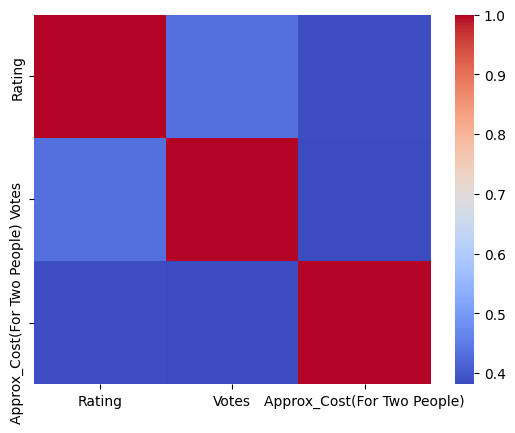

In [39]:
#Importing Seaborn for heatmap
import seaborn as sns
#Relation between different Columns
correlation = df.corr(numeric_only = True)
sns.heatmap(data = correlation,cmap = "coolwarm")

# Q1) Which cuisines are most popular across Bangalore?

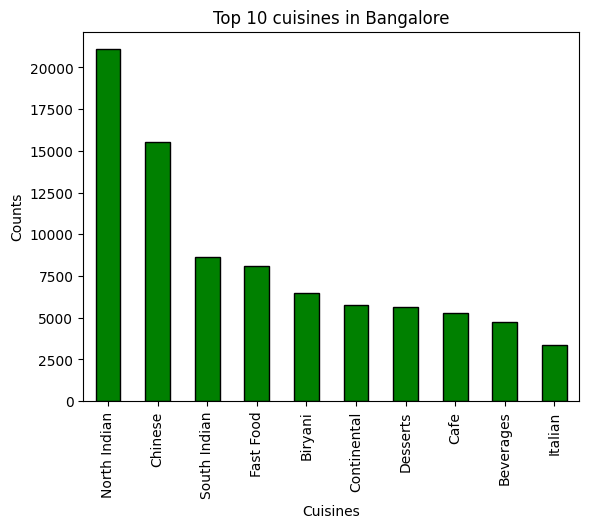

In [40]:
#Plotting Bar Graph for Top 10 cuisines in Bangalore
#Dropping Null Values
cuisine = df["Cuisines"].dropna()
#Splitting different strings 
cuisine = cuisine.str.split(",")
cuisine = cuisine.explode()
#Removing extra spaces
cuisine = cuisine.str.strip()
top_cuisine = cuisine.value_counts().head(10)
top_cuisine.plot(kind="bar" , color = "green",edgecolor = "black")
plt.title("Top 10 cuisines in Bangalore")
plt.xlabel("Cuisines")
plt.ylabel("Counts")
plt.savefig("Top 10 cuisines in Bangalore")
plt.show()

# Q2) What's the average cost for two across different restaurant types?

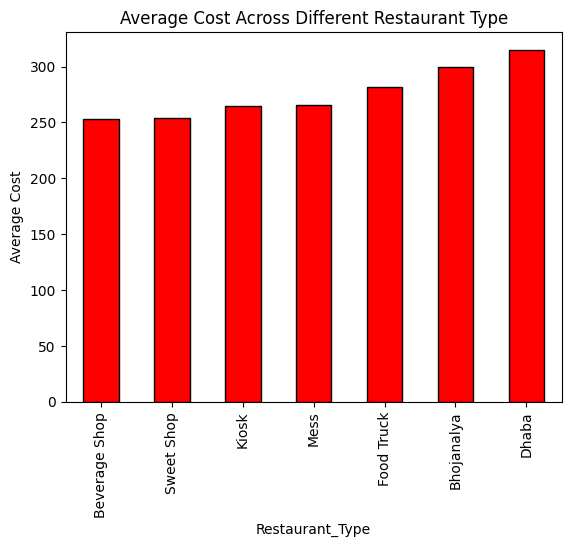

In [41]:
#Creating a Duplicate DataFrame
df_2 = df.copy()
df_2["Restaurant_Type"] = df_2["Restaurant_Type"].str.split(",")
df_2 = df_2.explode("Restaurant_Type")
df_2["Restaurant_Type"] = df_2["Restaurant_Type"].str.strip()
avg_cost = df_2.groupby("Restaurant_Type")["Approx_Cost(For Two People)"].mean().sort_values(ascending = True).head(7)
avg_cost.plot(kind = "bar" , color = "red",edgecolor = "black")
plt.title("Average Cost Across Different Restaurant Type")
plt.xlabel("Restaurant_Type")
plt.ylabel("Average Cost")
plt.savefig("Average Cost Across Different Restaurant Type")
plt.show()

# Q3) Do restaurants with online ordering have higher ratings than those without?

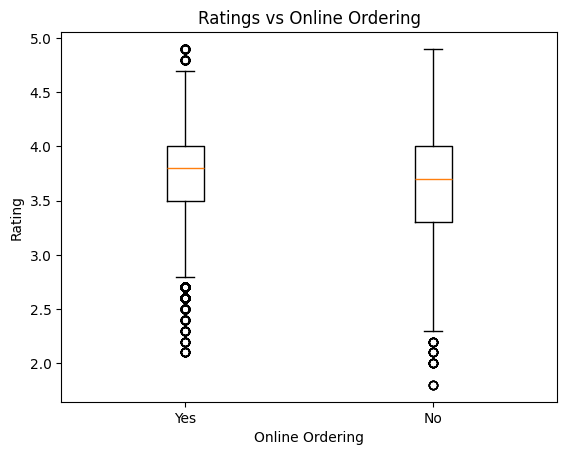

In [48]:
#Plotting Scatter Plot Between Rating & Online_Order_Availibility
yes = df[df["Online_Order_Availability"] == "Yes"]["Rating"].dropna()
no = df[df["Online_Order_Availability"] == "No"]["Rating"].dropna()

# Create boxplot
plt.boxplot([yes, no], tick_labels=["Yes", "No"])

plt.title("Ratings vs Online Ordering")
plt.xlabel("Online Ordering")
plt.ylabel("Rating")
plt.savefig("Ratings vs Online Ordering")
plt.show()

# Q4) Which neighbourhoods have the most restaurants, and which have the highest average ratings?

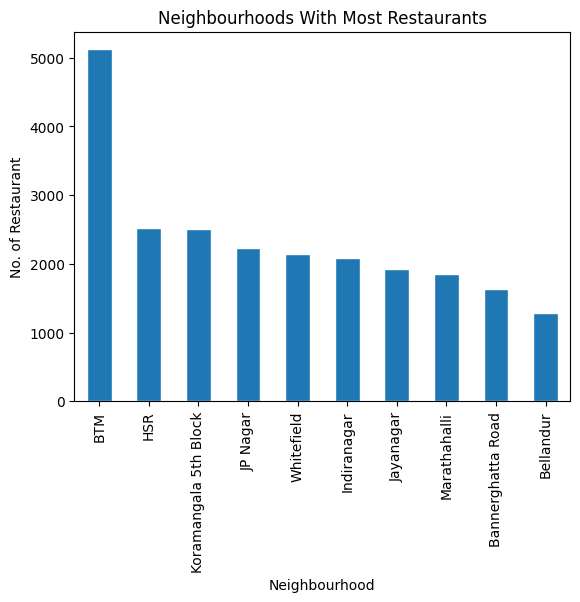

In [43]:
#Plotting Bar Graph for Neighbourhoods With Most Restaurants
more_res = df["Location"].value_counts().head(10)
more_res.plot(kind = "bar" ,edgecolor = "white" )
plt.title("Neighbourhoods With Most Restaurants")
plt.xlabel("Neighbourhood")
plt.ylabel("No. of Restaurant")
plt.savefig("Neighbourhoods With Most Restaurants")
plt.show()

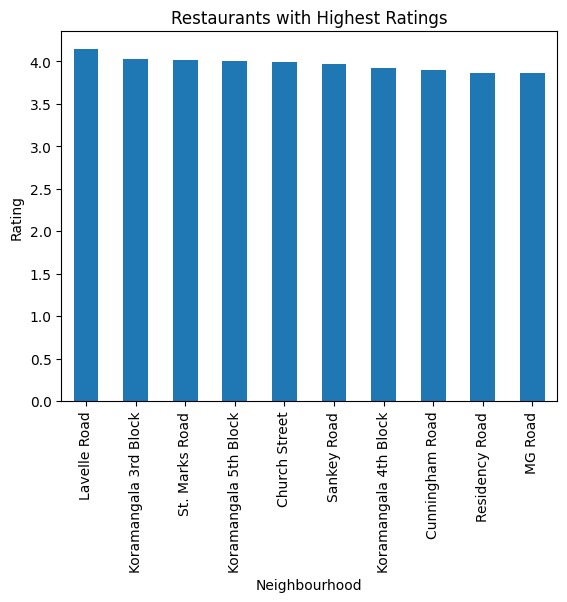

In [44]:
#Plotting Bar Graph for Restaurants with Highest Ratings 
highest_rating = df.groupby("Location")["Rating"].mean().sort_values(ascending = False)
highest_rating = highest_rating.head(10)
highest_rating.plot(kind = "bar")
plt.title("Restaurants with Highest Ratings")
plt.xlabel("Neighbourhood")
plt.ylabel("Rating")
plt.savefig("Restaurants with Highest Ratings")
plt.show()

# Q5) Is there a relationship between number of votes and restaurant rating?

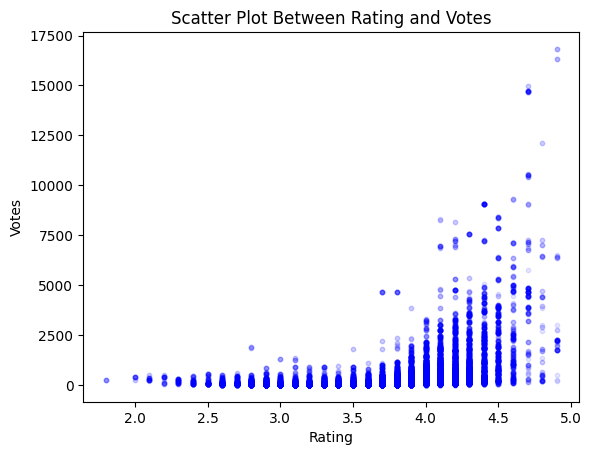

In [45]:
#Plotting Scatter Plot Between Rating and Votes
plt.scatter(df["Rating"],df["Votes"],c = "blue" , alpha = 0.1 , s = 10)
plt.title("Scatter Plot Between Rating and Votes")
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.savefig("Scatter Plot Between Rating and Votes")
plt.show()

# Q6) What percentage of restaurants offer table booking, and does it correlate with higher cost?

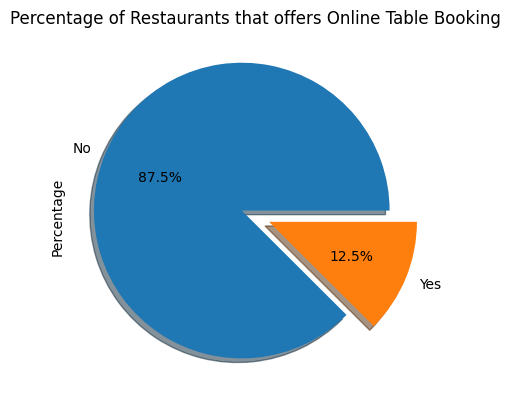

In [46]:
#Plotting Pie Chart for Percentage of Restaurants that offers Online Tabel Booking
explode = [0.1,0.1]
df["Table_Booking_Availability"].value_counts().plot(kind = "pie", autopct = "%1.1f%%", shadow = True , explode = explode)
plt.title("Percentage of Restaurants that offers Online Table Booking")
plt.ylabel("Percentage")
plt.savefig("Percentage of Restaurants that offers Online Table Booking")
plt.show()

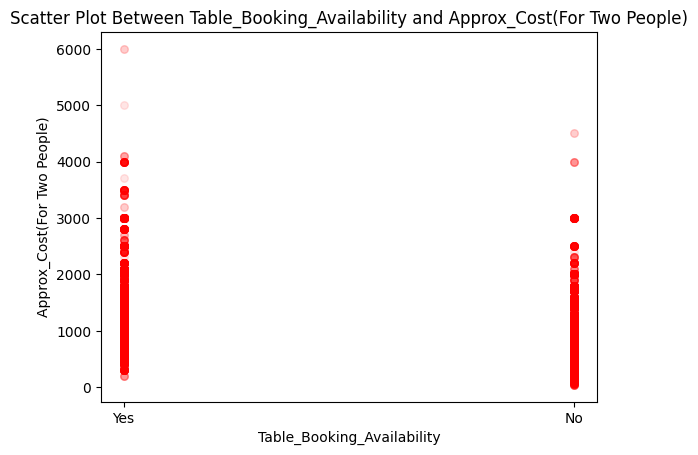

In [47]:
#Plotting Scatter Plot Between Table_Booking_Availibity and Approx_Cost(For Two People)
plt.scatter(df["Table_Booking_Availability"],df["Approx_Cost(For Two People)"],c = "red" , alpha = 0.1 , s = 30)
plt.title("Scatter Plot Between Table_Booking_Availability and Approx_Cost(For Two People)")
plt.xlabel("Table_Booking_Availability")
plt.ylabel("Approx_Cost(For Two People)")
plt.savefig("Scatter Plot Between Table_Booking_Availability and Approx_Cost(For Two People)")
plt.show()

## Source : Dataset Zomato Bangalore Restaurants from Kaggle.com

# Key Findings

### 1.Even in South Indian Region, North Indian Cuisines are at #1 Cuisines.
### 2.Least Average Cost Across Different Restaurant Type is at Beverage Shop & Sweet Shop (250).
### 3.Ratings of Restaurant is not Affected by Online Order Availability
### 4.BTM has almost twice the No. of Restaurants as of HSR.
### 5.Lavelle Road ,Koramangala 3rd Block ,St. Marks Road ,Koramangala 5th Block ,Church Street are Neighbourhoods with Highest Ratings.
### 6.Yes, Votes & Ratings Correlates with each other.
### 7.Almost 12.5% Restaurants provides Online Table Booking.
### 8.Online Table Booking Availability & Average Cost for two People does not Correlate.
